## <center>K-means Lab</center>

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [49]:
documents = [
    "This little kitty came to play when I was eating at a restaurant.",
    "Merley has the best squooshy kitten belly.",
    "Google Translate app is incredible.",
    "If you open 100 tab in google you get a smiley face.",
    "Best cat photo I've ever taken.",
    "Climbing ninja cat.",
    "Impressed with google map feedback.",
    "Key promoter extension for Google Chrome.",
    "My rescue cat loves to sleep in empty cardboard boxes.",
    "Google Drive makes sharing large files incredibly easy.",
    "That fluffy ginger cat just jumped right onto my laptop keyboard.",
    # "The new search algorithm update by Google prioritizes helpful content.",
    # "Feeding stray kittens in the neighborhood is so rewarding."
]

In [50]:
# Data Cleaning
vectorizer = TfidfVectorizer(stop_words='english')

In [51]:
X = vectorizer.fit_transform(documents)
print(vectorizer.vocabulary_)
print(vectorizer.get_feature_names_out())

{'little': 31, 'kitty': 28, 'came': 5, 'play': 39, 'eating': 12, 'restaurant': 42, 'merley': 35, 'best': 3, 'squooshy': 47, 'kitten': 27, 'belly': 2, 'google': 19, 'translate': 50, 'app': 1, 'incredible': 21, 'open': 37, '100': 0, 'tab': 48, 'smiley': 46, 'face': 14, 'cat': 7, 'photo': 38, 've': 51, 'taken': 49, 'climbing': 9, 'ninja': 36, 'impressed': 20, 'map': 34, 'feedback': 15, 'key': 25, 'promoter': 40, 'extension': 13, 'chrome': 8, 'rescue': 41, 'loves': 32, 'sleep': 45, 'cardboard': 6, 'boxes': 4, 'drive': 10, 'makes': 33, 'sharing': 44, 'large': 30, 'files': 16, 'incredibly': 22, 'easy': 11, 'fluffy': 17, 'ginger': 18, 'just': 24, 'jumped': 23, 'right': 43, 'laptop': 29, 'keyboard': 26}
['100' 'app' 'belly' 'best' 'boxes' 'came' 'cardboard' 'cat' 'chrome'
 'climbing' 'drive' 'easy' 'eating' 'extension' 'face' 'feedback' 'files'
 'fluffy' 'ginger' 'google' 'impressed' 'incredible' 'incredibly' 'jumped'
 'just' 'key' 'keyboard' 'kitten' 'kitty' 'laptop' 'large' 'little'
 'loves'

In [42]:
true_k = 2
model = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=1)
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",100
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [43]:
print(model.labels_)

[1 1 0 0 1 1 0 0 1 0 1 0 1]


In [44]:
Y = vectorizer.transform(["My cat is hungry."])
prediction = model.predict(Y)
print(prediction)

[1]


In [45]:
print("Top terms per cluster:")
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
for i in range(true_k):
    print(f"Cluster {i}:")
    for ind in order_centroids[i, :10]:
        print(f" {terms[ind]}")
    print()

Top terms per cluster:
Cluster 0:
 google
 translate
 incredible
 map
 impressed
 feedback
 app
 promoter
 chrome
 extension

Cluster 1:
 cat
 best
 ninja
 climbing
 photo
 ve
 taken
 squooshy
 kitten
 merley



---

In [55]:
from sklearn.datasets import fetch_20newsgroups

categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
dataset = fetch_20newsgroups(subset='all', categories=categories, shuffle=True, random_state=42)

X_test = dataset.data
X_test_processed = vectorizer.fit_transform(X_test)

In [56]:
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_test_processed)
# X_2d = svd.fit_transform(X)


3 | Top terms per cluster:
Cluster 0:
    edu
    com
    subject
    lines
    organization
    university
    posting
    writes
    nntp
    host

Cluster 1:
    pitt
    banks
    geb
    gordon
    edu
    sandvik
    com
    jaeger
    cs
    islamic

Cluster 2:
    god
    jesus
    people
    edu
    believe
    bible
    church
    faith
    christians
    sin



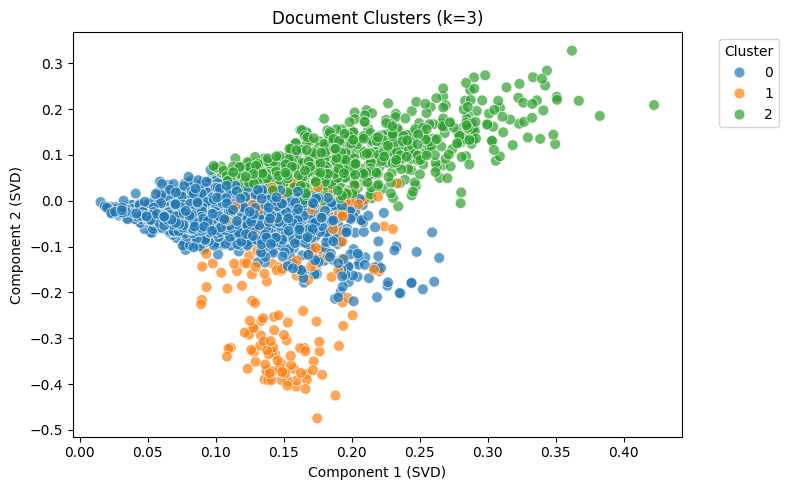


4 | Top terms per cluster:
Cluster 0:
    graphics
    edu
    image
    files
    file
    university
    3d
    lines
    subject
    thanks

Cluster 1:
    edu
    com
    subject
    lines
    organization
    article
    writes
    university
    people
    know

Cluster 2:
    god
    jesus
    people
    believe
    edu
    bible
    faith
    sin
    church
    christ

Cluster 3:
    keith
    sgi
    pitt
    banks
    livesey
    geb
    gordon
    caltech
    edu
    solntze



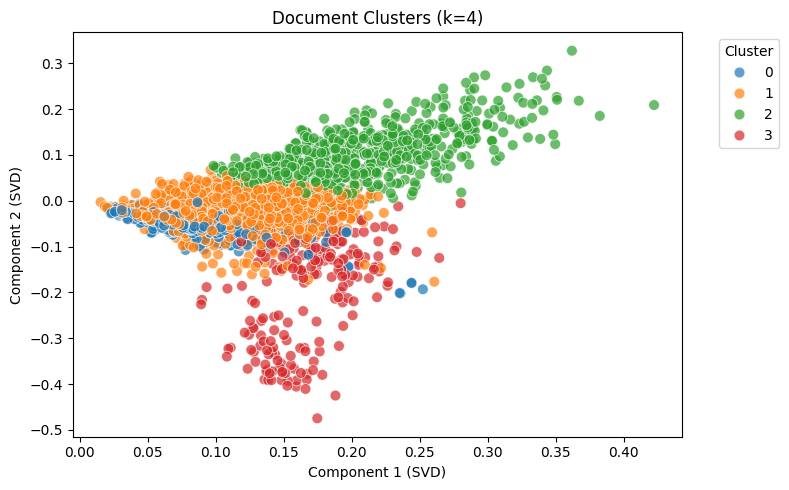


5 | Top terms per cluster:
Cluster 0:
    uk
    ac
    mathew
    mantis
    kidney
    edu
    mcc
    lilley
    stones
    university

Cluster 1:
    edu
    com
    subject
    lines
    organization
    university
    graphics
    posting
    article
    know

Cluster 2:
    keith
    sgi
    edu
    livesey
    caltech
    com
    solntze
    wpd
    morality
    jon

Cluster 3:
    geb
    pitt
    banks
    gordon
    cs
    edu
    dsl
    cadre
    shameful
    surrender

Cluster 4:
    god
    jesus
    people
    edu
    believe
    bible
    church
    faith
    sin
    christians



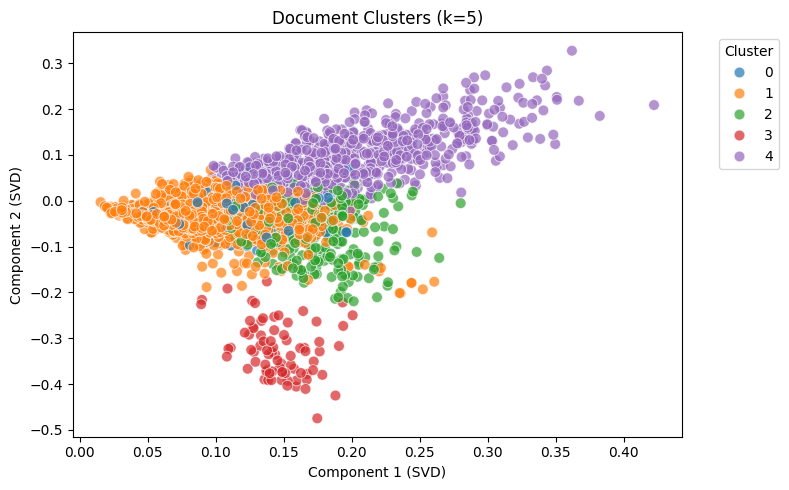


6 | Top terms per cluster:
Cluster 0:
    god
    jesus
    sin
    christ
    hell
    edu
    bible
    believe
    people
    mary

Cluster 1:
    keith
    sgi
    livesey
    caltech
    solntze
    wpd
    jon
    schneider
    com
    edu

Cluster 2:
    graphics
    edu
    image
    university
    file
    files
    3d
    lines
    subject
    organization

Cluster 3:
    edu
    com
    subject
    lines
    msg
    organization
    article
    university
    writes
    know

Cluster 4:
    edu
    people
    god
    com
    christian
    religion
    writes
    don
    article
    think

Cluster 5:
    geb
    pitt
    banks
    gordon
    cs
    edu
    dsl
    cadre
    shameful
    surrender



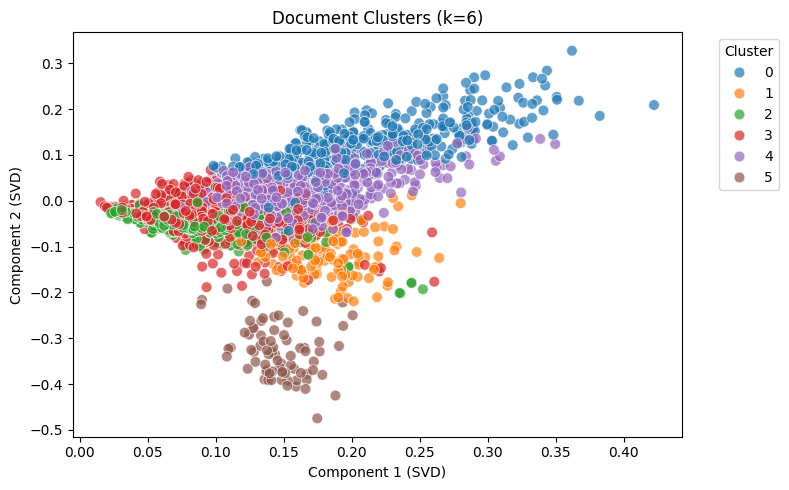


7 | Top terms per cluster:
Cluster 0:
    cobb
    uiuc
    morality
    frank
    alexia
    lis
    cso
    moral
    objective
    edu

Cluster 1:
    god
    jesus
    people
    believe
    edu
    faith
    bible
    sin
    church
    christ

Cluster 2:
    edu
    com
    subject
    lines
    organization
    article
    writes
    university
    know
    people

Cluster 3:
    graphics
    edu
    image
    file
    files
    university
    3d
    program
    lines
    thanks

Cluster 4:
    pitt
    geb
    banks
    gordon
    ai
    edu
    cs
    georgia
    uga
    n3jxp

Cluster 5:
    msg
    dyer
    yeast
    food
    candida
    harvard
    noring
    spdcc
    rind
    sensitivity

Cluster 6:
    keith
    sgi
    livesey
    caltech
    wpd
    solntze
    jon
    schneider
    com
    edu



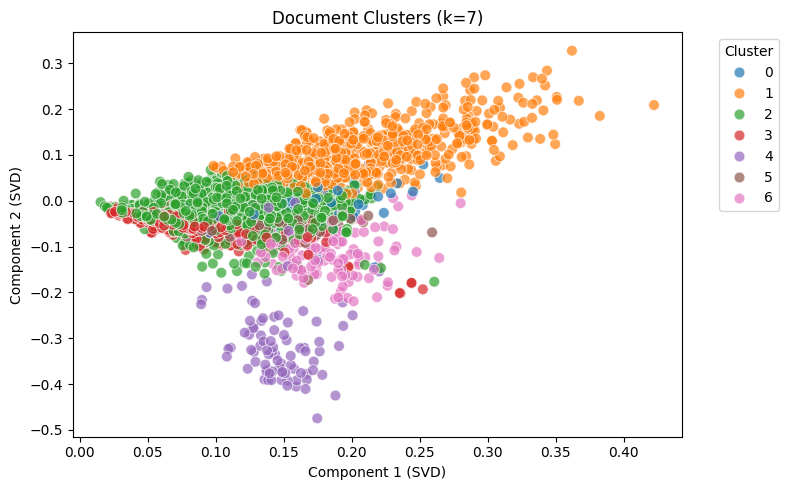


8 | Top terms per cluster:
Cluster 0:
    msg
    dyer
    food
    sensitivity
    chinese
    spdcc
    superstition
    carl
    sol1
    com

Cluster 1:
    keith
    sgi
    livesey
    caltech
    solntze
    wpd
    jon
    schneider
    cco
    edu

Cluster 2:
    edu
    com
    writes
    subject
    lines
    article
    organization
    people
    university
    christian

Cluster 3:
    edu
    com
    doctor
    medical
    ai
    yeast
    cancer
    disease
    university
    treatment

Cluster 4:
    god
    jesus
    people
    believe
    sin
    faith
    bible
    christ
    edu
    christians

Cluster 5:
    islam
    sandvik
    jaeger
    islamic
    rushdie
    bu
    gregg
    kent
    com
    ico

Cluster 6:
    graphics
    edu
    image
    university
    lines
    subject
    organization
    thanks
    posting
    com

Cluster 7:
    geb
    pitt
    banks
    gordon
    cs
    edu
    cadre
    dsl
    shameful
    n3jxp



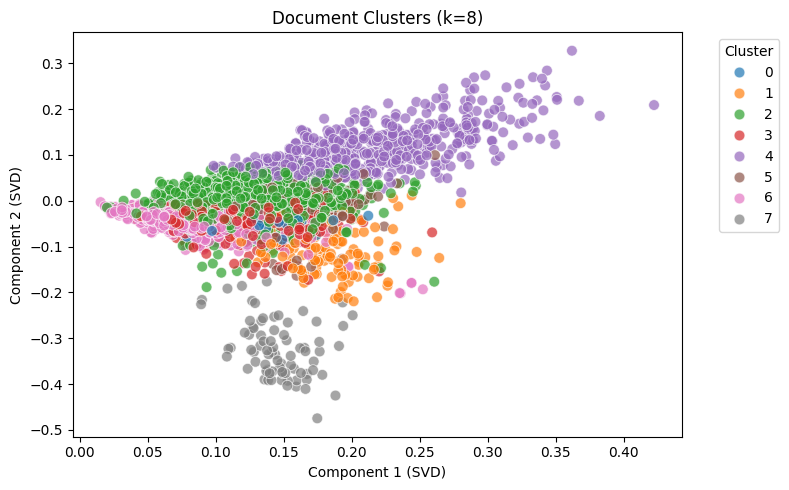


9 | Top terms per cluster:
Cluster 0:
    keith
    sgi
    livesey
    caltech
    wpd
    solntze
    jon
    schneider
    cco
    edu

Cluster 1:
    islam
    sandvik
    jaeger
    islamic
    rushdie
    bu
    gregg
    kent
    newton
    apple

Cluster 2:
    graphics
    edu
    image
    university
    file
    files
    lines
    thanks
    subject
    3d

Cluster 3:
    edu
    com
    subject
    lines
    organization
    writes
    article
    university
    people
    know

Cluster 4:
    god
    jesus
    people
    believe
    sin
    faith
    bible
    christ
    edu
    christians

Cluster 5:
    geb
    pitt
    banks
    gordon
    cs
    edu
    dsl
    cadre
    shameful
    surrender

Cluster 6:
    ai
    georgia
    uga
    mcovingt
    covington
    athens
    michael
    programs
    706
    aisun3

Cluster 7:
    msg
    dyer
    yeast
    food
    candida
    harvard
    noring
    spdcc
    rind
    sensitivity

Cluster 8:
    tek
    ico
    petch
 

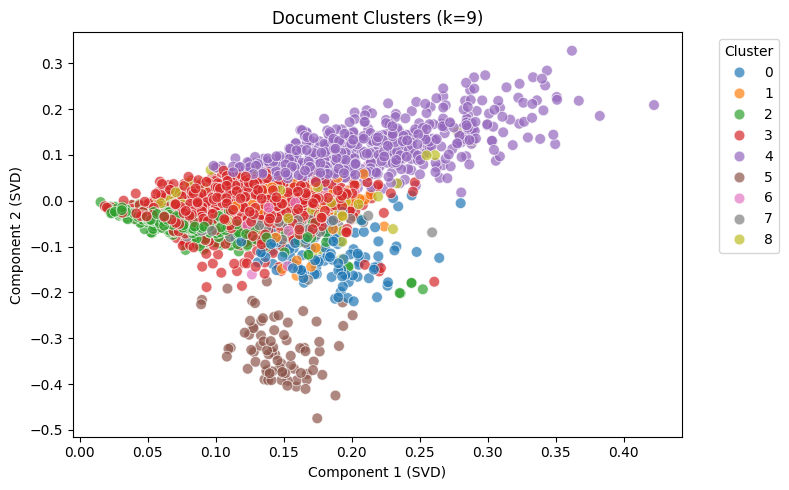


10 | Top terms per cluster:
Cluster 0:
    hell
    god
    eternal
    jesus
    heaven
    psuvm
    believe
    edu
    psu
    atheists

Cluster 1:
    yeast
    candida
    noring
    rind
    harvard
    edu
    quack
    bih
    radford
    enterprise

Cluster 2:
    edu
    com
    subject
    lines
    organization
    article
    writes
    msg
    university
    people

Cluster 3:
    edu
    islam
    sandvik
    okcforum
    osrhe
    islamic
    jaeger
    com
    cobb
    rushdie

Cluster 4:
    church
    mary
    sin
    god
    catholic
    doctrine
    jesus
    sun
    baptism
    original

Cluster 5:
    graphics
    image
    bit
    file
    images
    files
    24
    windows
    edu
    program

Cluster 6:
    geb
    pitt
    banks
    gordon
    cs
    edu
    dsl
    cadre
    shameful
    surrender

Cluster 7:
    god
    jesus
    people
    christians
    faith
    edu
    christianity
    christian
    believe
    bible

Cluster 8:
    edu
    universit

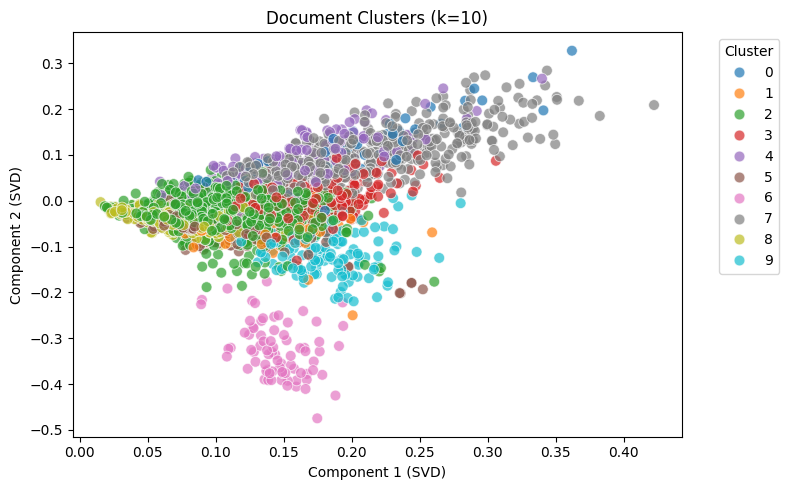

In [57]:
inertia_values = []
silhouette_scores = []

for k in range(3, 11):
    model = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=1)
    cluster_labels = model.fit_predict(X_test_processed)
    # cluster_labels = model.fit_predict(X)

    inertia_values.append(model.inertia_)

    score = silhouette_score(X_test_processed, cluster_labels)
    # score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

    print(f"\n{'='*40}")
    print(f"{k} | Top terms per cluster:")
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]
    terms = vectorizer.get_feature_names_out()

    for i in range(k):
        print(f"Cluster {i}:")
        for ind in order_centroids[i, :10]:
            print(f"    {terms[ind]}")
        print()

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=cluster_labels,
        palette='tab10',
        s=60,
        alpha=0.7
    )

    plt.title(f"Document Clusters (k={k})")
    plt.xlabel("Component 1 (SVD)")
    plt.ylabel("Component 2 (SVD)")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.show()

### Q: How can we determine the optimal value for $k$?
A: We can optimize $k$ by plotting the model's performance across different cluster sizes. We typically use the Elbow Method, looking for an inflection point where the inertia stops dropping rapidly, or the Silhouette Score, looking for the maximum score which indicates highly distinct clusters.


EVALUATION METRICS:


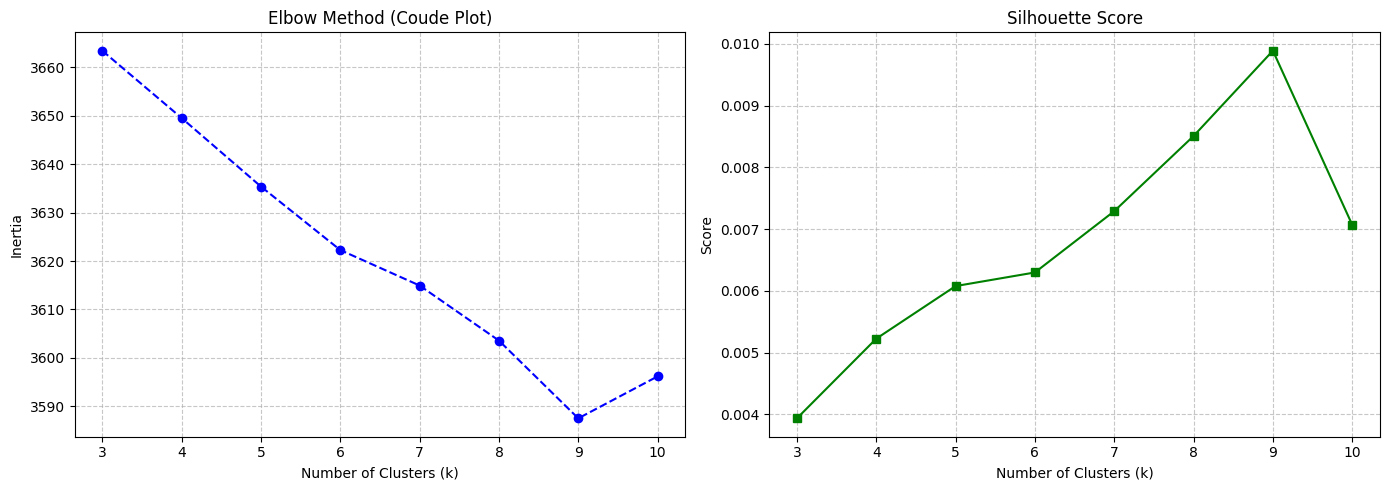

In [58]:
print(f"\n{'='*40}")
print("EVALUATION METRICS:")

k_range = range(3, 11)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
ax1.set_title("Elbow Method (Coude Plot)")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title("Silhouette Score")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Score")
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Conclusion: Optimal Cluster Size (k = 7)

Based on the evaluation metrics, the most optimal number of clusters for this dataset is **k = 7**. 

* **Silhouette Score:** The score climbs steadily before reaching a distinct plateau between k = 7 and k = 8. This plateau indicates that adding an 8th cluster provides no mathematical improvement to the separation of the groups. While the score rises again at k = 9, this is a common artifact in text clustering where the model begins to overfit by isolating single documents into their own tiny clusters.
* **Elbow Method (Inertia):** The inertia plot supports this conclusion. The sharpest drops in within-cluster variance resolve around k = 6 and k = 7, after which the curve transitions into a predictable, linear descent.